<a href="https://colab.research.google.com/github/Marlon-Sbardelatti/machine-learning/blob/feature%2Ftrabalho-04/trabalho-04/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Equipe**: 01<br>
> **Estudantes**: Cristina Siewert Jansen, Marlon Sbardelatti e Sofia Sousa Lindner

# **REDES NEURAIS ARTIFICIAIS**

# PARTE 2: Redes Neurais e CNN - Identificação de Objetos

Neste trabalho iremos fazer a identificação de um conjunto de dados de imagens de artigos de Zalando chamado Fashion-MNIST, que consiste em um conjunto de treinamento de 60.000 exemplos e um conjunto de teste de 10.000 exemplos. Cada exemplo é uma imagem em tons de cinza 28x28, associada a um rótulo de 10 classes.

Fonte: https://www.tensorflow.org/datasets/catalog/fashion_mnist?hl=pt-br

## **ATIVIDADE:**

**Descrição:**

Nesta atividade, você receberá um código de uma Rede Neural Artificial e uma Rede Neural Convolucional (CNN) implementada. Sua tarefa é analisar o código fornecido e fazer uma interpretação detalhada de cada linha, identificando e explicando as principais etapas, camadas e operações realizadas pela RNA e pela CNN.

**Instruções:**

1. Preencha o código com comentários em cada linha, explicando sua função e propósito.
2. Analise o código cuidadosamente para entender como a CNN é configurada.
3. Identifique e explique as camadas de convolução, camadas de pooling, camadas densas, funções de ativação, tamanhos dos filtros, número de neurônios, etc.
4. Identifique quais técnicas de regularização ou otimização formam utilizadas no código e explique como elas contribuem para o desempenho e a generalização do modelo.
5. Comente sobre a função de ativação utilizada na camada de saída.
6. Descreva os hiperparâmetros e ajustes do modelo, como a taxa de aprendizado, número de épocas de treinamento e o tratamento dos conjuntos de dados de treinamento e teste.
7. Faça uma avaliação descritiva dos resultados das Redes Neurais implementadas.



**Entregável:**

Prepare uma análise detalhada do código fornecido, destacando as principais características da CNN e como ela é configurada para a tarefa em questão. Se necessário, inclua observações sobre o potencial de melhoria ou otimização do modelo.

Esta atividade visa consolidar seu conhecimento sobre CNNs, ajudando a compreender como uma Rede Neural Convolucional é implementada e configurada para tarefas específicas.

In [26]:
# Importa bibliotecas do Tensorflow sobre CNNs
import tensorflow as tf
from tensorflow import keras

In [27]:
# Importa bibliotecas para manipulação do dataset
import numpy as np                    # Permite transformação dos dados através de tensores
import pandas as pd                   # Permite uso de Dataframes
from matplotlib import pyplot as plt  # Permite plotagem
%matplotlib inline

## Importando base de dados

In [28]:
# Atribui dataset Fashion-MNIST à variável
fashion_mnist = keras.datasets.fashion_mnist


In [29]:
# Realiza download do dataset, separando em X (features) e y (labels) de teste e treino
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

In [30]:

print(X_train_full.shape) # Imprime dimensões do tensor de amostras de TREINO
print(y_train_full.shape) # Imprime total de rótulos de TREINO

print(X_test.shape)       # Imprime dimensões do tensor de amostras de TESTE
print(y_test.shape)       # Imprime total de rótulos de TESTE

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


A saída da célula confirma as informações fornecidas sobre o dataset: `X_train_full` e `X_test` são tensores tridimensionais cujo shape revela, respectivamente, número de amostras, altura e largura de cada imagem, em pixels. A ausência de uma quarta dimensão também confirma o fato de estarem em grayscale.<br>

Dessa forma, pode-se afirmar que o conjunto de treino é composto por 60.000 imagens 28x28, enquanto o conjunto de teste é composto por 10.000 imagens 28x28, o que configura um split de ≈ 16,67% para teste.

In [31]:
# Divide eixo X do conjunto de treinamento em: validação e treino
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0 # Normaliza intensidade dos pixels
                                                                            # para intervalo [0,1]

# Divide eixo y do conjunto de treinamento em: validação e treino
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

O conjunto original de treinamento é dividido em dois subconjuntos: 5000 imagens são reservadas para validação do modelo, enquanto as 55000 restantes são utilizadas para treinamento, ou seja, ajustar os pesos da rede. Essa divisão configura um split de ≈ 9% para validação.<br>

Em seguida, os valores dos pixels, originalmente no intervalo [0, 255], são normalizados para [0, 1] por meio da divisão por 255 (branco), permitindo uma convergência mais estável do processo de aprendizado.

In [32]:
# Cria lista de labels para facilitar a leitura das predições (número -> nome)
nomes_classes = ["camisa/top", "calca", "casaco", "vestido", "jaqueta",
               "sandalia", "camiseta", "tenis", "bolsa", "bota"]

In [33]:
# Testa verificar a classe da amostra de índice 5 do conjunto de treino,
# convertendo o número do rótulo para o nome correspondente
nomes_classes[y_train[5]]

'bota'

In [34]:
# Imprime valor da amostra de índice 5: pixels normalizados com valor entre [0,1]
X_train[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

bota


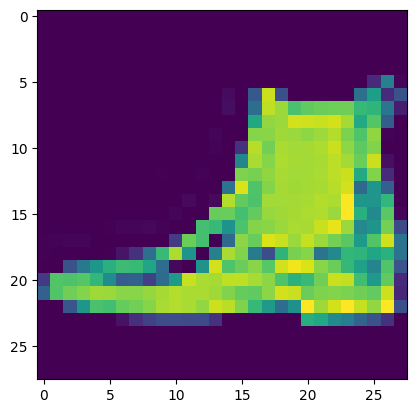

In [35]:
exemplo_n = 5

# Imprime nome da classe da amostra 5
print(nomes_classes[y_train[exemplo_n]])

# Exibe a amostra 5 como imagem, com interpolação "nearest"
# para manter os pixels visivelmente separados
plt.imshow(X_train[exemplo_n], interpolation='nearest')
plt.show()

##  Rede Neural Artificial com Keras

In [38]:
nn = keras.models.Sequential()

# Converte cada imagem 28x28 em um vetor unidimensional
nn.add(keras.layers.Flatten(input_shape=[28, 28]))

# 1ª camada oculta com 300 neurônios para extração inicial
nn.add(keras.layers.Dense(300, activation="relu"))

# Desliga aleatoriamente 10% dos neurônios durante o treinamento para reduzir overfitting
nn.add(keras.layers.Dropout(rate=0.1))

# 2ª camada oculta com 100 neruônios para aprender representações mais abstratas
nn.add(keras.layers.Dense(100, activation="relu"))

# Novo dropout de 10% para melhorar a capacidade de generalização
nn.add(keras.layers.Dropout(rate=0.1))

# Camada de saída com 10 neurônios, um para cada classe de objeto
nn.add(keras.layers.Dense(10, activation="softmax"))

nn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

### Compilando e treinando o modelo

In [39]:
%time
# Compila o modelo
nn.compile(
  loss="sparse_categorical_crossentropy", # Função de perda adequada pra múltiplas classes
  optimizer="sgd",                        # Otimizador SGD pra ajuste de learning rate
  metrics=["accuracy"]                    # Define acurácia como métrica de validação
)

# Realiza o treinamento do modelo com os subconjuntos de treinamento e 5 épocas (passadas sobre o dataset)
history_nn = nn.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 33.9 µs
Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7358 - loss: 0.7861 - val_accuracy: 0.8256 - val_loss: 0.5220
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8152 - loss: 0.5353 - val_accuracy: 0.8426 - val_loss: 0.4575
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8330 - loss: 0.4789 - val_accuracy: 0.8536 - val_loss: 0.4203
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8436 - loss: 0.4436 - val_accuracy: 0.8670 - val_loss: 0.3927
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8515 - loss: 0.4202 - val_accuracy: 0.8634 - val_loss: 0.3810


### Visualizar a performance

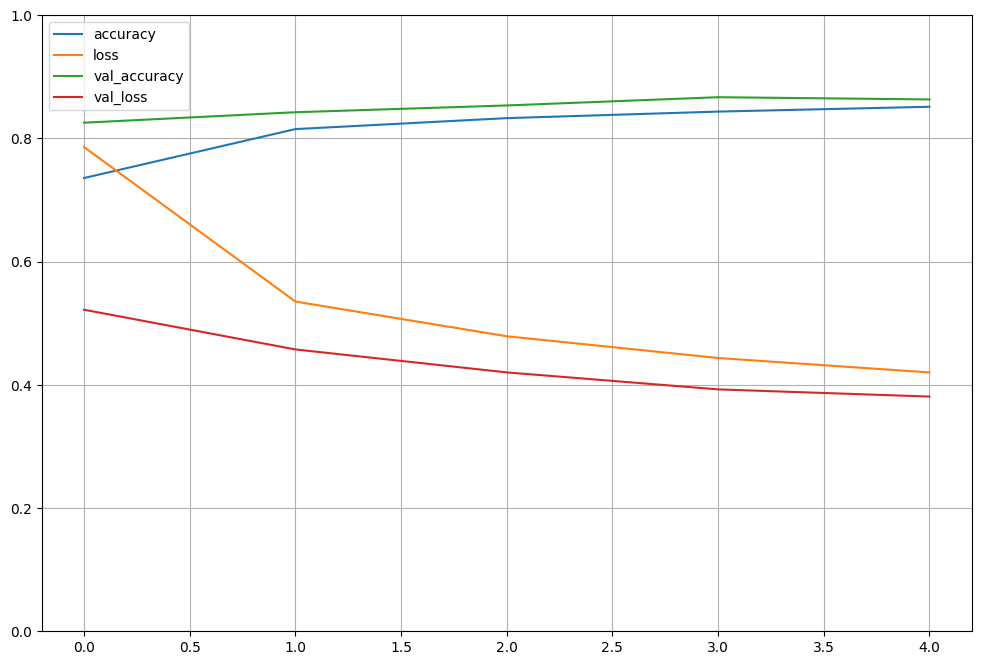

In [40]:
# Transforma histórico do treinamento em dataframe
pd.DataFrame(history_nn.history).plot(figsize=(12, 8))

# Habilita grid na imagem
plt.grid(True)

# Altera escala do eixo y para intervalo [0,1]
plt.gca().set_ylim(0, 1)

# Exibe gráfico final de performance
plt.show()

As acurácias de treino e validação crescem conforme tempo de treinamento, sendo que, como esperado, a de validação é levemente mais estável. Com relação à perda, ambas baixaram conforme treinamento, mas a de treinamento demorou mais para alcançar certa estabilidade por conta do Dropout ativado, que, propositalmente, acaba gerando mais erro.

### Avaliar o modelo

In [45]:
# Imprime total de perda e acurácia para dados de TESTE
nn.evaluate(X_test, y_test,verbose=1) # Perda = 70,1% e Acurácia = 81,15%

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8115 - loss: 70.1111


[70.11112213134766, 0.8115000128746033]

###Realizar uma Previsão

In [48]:
# Seleciona apenas as 4 primeiras imagens de TESTE
X_novo = X_test[:4]

# Realiza previsão das 4 imagens, produzindo uma matriz de probabilidades
y_proba = nn.predict(X_novo)

# Exibe matriz de probabilidades para cada uma das 10 classes
y_proba

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

Por ter sido usada a camada de saída Softmax com 10 neurônios, para cada amostra de entrada, é produzida uma lista de probabilidades, uma para cada classe de objeto. Dessa forma, o resultado da célula é uma matriz 4x10, sendo que, para cada linha (amostra), a rede demonstrou 100% de probabilidade para a classe prevista.

In [49]:
# Faz novamente a previsão, dessa vez selecionando a classe com maior probabilidade
y_pred = np.argmax(nn.predict(X_novo), axis=-1)

# Imprime número das classes prevista
print(y_pred)

# Imprime nome de cada classe prevista
print(np.array(nomes_classes)[y_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
[9 2 1 1]
['bota' 'casaco' 'calca' 'calca']


### Verificar os resultados

In [51]:
# Recupera rótulos reais das 4 primeiras imagens do conjunto de TESTE
y_novo = y_test[:4]

# Imprime número dos rótulos
print(y_novo)

# Imprime nome das classes
np.array(nomes_classes)[y_pred]

[9 2 1 1]


array(['bota', 'casaco', 'calca', 'calca'], dtype='<U10')

calca


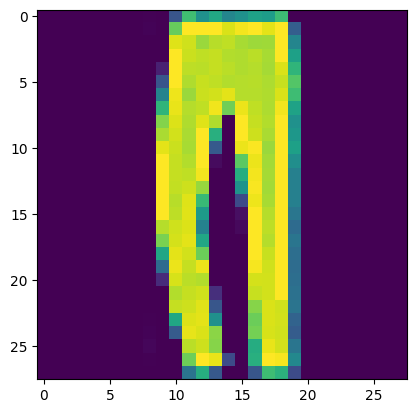

In [52]:
# example_n = 201
print(nomes_classes[y_pred[2]])
plt.imshow(X_novo[2], interpolation='nearest')
plt.show()

## Treinando CNN com Keras

In [ ]:
cnn = keras.models.Sequential([
keras.layers.InputLayer(input_shape = (28,28,1)),
keras.layers.Conv2D(64,5, activation='relu', padding='same', kernel_initializer='glorot_uniform'),
keras.layers.MaxPool2D(2),
keras.layers.Conv2D(128,3, activation='relu', padding='same'),
keras.layers.Conv2D(128,3, activation='relu', padding='same'),
keras.layers.MaxPool2D(2),
keras.layers.Conv2D(258,3, activation='relu', padding='same'),
keras.layers.Conv2D(258,3, activation='relu', padding='same'),
keras.layers.MaxPool2D(2),
keras.layers.Flatten(),
keras.layers.Dense(128, activation="relu"),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(64, activation="relu"),
keras.layers.Dropout(rate=0.5),
keras.layers.Dense(10, activation="softmax")])


In [ ]:
cnn.summary()

In [ ]:
print(X_train.shape)
X_train_new = X_train.reshape(X_train.shape[0], X_train.shape[1], X_train.shape[2],1)
X_valid_new = X_valid.reshape(X_valid.shape[0], X_valid.shape[1], X_valid.shape[2],1)
X_test_new = X_test.reshape(X_test.shape[0], X_test.shape[1], X_test.shape[2],1)
print(X_train_new.shape)

In [ ]:
cnn.compile(loss="sparse_categorical_crossentropy",
              optimizer="sgd",
              metrics=["accuracy"])
history_cnn = cnn.fit(X_train_new, y_train, epochs=20, validation_data=(X_valid_new, y_valid))

### Avaliar o modelo

In [ ]:
cnn.evaluate(X_test_new, y_test,verbose=1)

In [ ]:
pd.DataFrame(history_cnn.history).plot(figsize=(12, 8))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()